In [217]:
import numpy as np
import pandas as pd


In [218]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [219]:
path = "interactions_data_5000_user/"

In [220]:
df_movies = pd.read_csv(path + 'movies_data.csv')
df_interactions = pd.read_csv(path + 'interactions_data.csv')

In [221]:
df_movies.rename(columns={'id': 'movie_id'}, inplace=True)
df_movies.head()

,movie_id,title,description,genres,actors,directors
0,37702,Forbidden City Cop,An imperial agent gets ridiculed for his vario...,"Adventure, Action, Comedy","Stephen Chow, Carina Lau, Carman Lee Yeuk-Tung...",Vincent Kok Tak-Chiu
1,1290821,Shelter,A man living in self-imposed exile on a remote...,"Action, Thriller, Crime","Jason Statham, Bodhi Rae Breathnach, Bill Nigh...",Ric Roman Waugh
2,1171145,Crime 101,When an elusive thief whose high-stakes heists...,"Thriller, Crime","Chris Hemsworth, Mark Ruffalo, Halle Berry, Ba...",Bart Layton
3,1198994,Send Help,Two colleagues become stranded on a deserted i...,"Horror, Comedy, Thriller","Rachel McAdams, Dylan O'Brien, Edyll Ismail, D...",Sam Raimi
4,840464,Greenland 2: Migration,Having found the safety of the Greenland bunke...,"Adventure, Thriller, Science Fiction","Gerard Butler, Morena Baccarin, Roman Griffin ...",Ric Roman Waugh


In [222]:
df_interactions.head()

,user_id,movie_id,rating,max_progress_percent,favourite,in_watchlist,view_count,last_watched_at
0,10,9315,NaN,25,0,1,1,2026-02-09 23:51:55.273267
1,10,319888,2.0,45,0,0,1,2025-12-12 23:51:55.273267
2,10,33205,NaN,35,0,0,1,2026-02-04 23:51:55.274268
3,10,664561,NaN,31,0,1,1,2025-12-26 23:51:55.275265
4,10,9013,NaN,19,0,0,1,2025-10-10 23:51:55.275265


In [223]:
def calculate_base_score(row, weights):
    v_progress = row['max_progress_percent'] / 100
    v_rating = row['rating'] / 5.0 if pd.notnull(row['rating']) else None
    v_fav = float(row['favourite'])
    v_watchlist = float(row['in_watchlist'])
    v_view_count = np.log(max(row['view_count'], 1)) / np.log(10)

    # Tính điểm theo từng thành phần hợp lệ
    numerator = (
        weights['progress'] * v_progress
        + weights['favourite'] * v_fav
        + weights['watchlist'] * v_watchlist
        + weights['view_count'] * v_view_count
    )
    denominator = (
        weights['progress']
        + weights['favourite']
        + weights['watchlist']
        + weights['view_count']
    )

    # Chỉ cộng rating khi có dữ liệu
    if v_rating is not None:
        numerator += weights['rating'] * v_rating
        denominator += weights['rating']

    return numerator / denominator * 10

In [224]:
weights = {
    'progress': 3.0,
    'rating': 4.1,
    'favourite': 4.5,
    'watchlist': 2.0,
    'view_count': 1.1
}

df_interactions['base_score'] = df_interactions.apply(calculate_base_score, axis=1, weights=weights)

In [225]:
def add_time_features(df):
    df = df.copy()
    df["last_watched_at"] = pd.to_datetime(
        df["last_watched_at"], errors="coerce"
    )
    today = pd.Timestamp.now().normalize()
    df["day_diff"] = (
        today - df["last_watched_at"].dt.normalize()
    ).dt.days

    return df

In [226]:
df_interactions = add_time_features(df_interactions)


In [227]:
# Xác định decay factor lambda dựa trên nửa đời (half-life)
HALF_LIFE_DAYS = 30
decay_lambda = np.log(2) / HALF_LIFE_DAYS

print(f"Decay factor (lambda) for a half-life of {HALF_LIFE_DAYS} days: {decay_lambda:.6f}")

def cal_score_on_time(df, lam):
    df = df.copy()

    df['heuristic_score'] = df['base_score'] * np.exp(-lam * df['day_diff'])

    return df

df_interactions = cal_score_on_time(df_interactions, decay_lambda)
df_interactions

Decay factor (lambda) for a half-life of 30 days: 0.023105


,user_id,movie_id,rating,max_progress_percent,favourite,in_watchlist,view_count,last_watched_at,base_score,day_diff,heuristic_score
0,10,9315,NaN,25,0,1,1,2026-02-09 23:51:55.273267,2.594340,52,0.780264
1,10,319888,2.0,45,0,0,1,2025-12-12 23:51:55.273267,2.034014,111,0.156510
2,10,33205,NaN,35,0,0,1,2026-02-04 23:51:55.274268,0.990566,57,0.265416
3,10,664561,NaN,31,0,1,1,2025-12-26 23:51:55.275265,2.764151,97,0.293922
4,10,9013,NaN,19,0,0,1,2025-10-10 23:51:55.275265,0.537736,174,0.009652
...,...,...,...,...,...,...,...,...,...,...,...
275052,5000,299,4.0,92,0,0,3,2026-01-20 00:16:43.092657,4.465873,72,0.846125
275053,5000,927,NaN,33,0,0,1,2026-01-01 00:16:43.093612,0.933962,91,0.114079
275054,5000,564147,4.0,77,0,0,2,2025-12-02 00:16:43.095954,4.027982,121,0.245999
275055,5000,152042,5.0,89,1,0,4,2026-01-28 00:16:43.095954,8.117188,64,1.850156


In [228]:
def clean_data(x):
    if isinstance(x, list):
        return [str.lower(i.replace(" ", "")) for i in x]
    else:
        if isinstance(x, str):
            # Xóa khoảng trắng giữa các tên riêng (ví dụ: 'Action, Sci-Fi' -> 'action,sci-fi')
            # Sau đó xóa dấu phẩy để tạo thành chuỗi các từ đơn
            return x.replace(" ", "").lower().replace(",", " ")
        else:
            return ''

In [229]:
def create_soup(data_row):
    # Làm sạch các trường dữ liệu
    genres = clean_data(data_row['genres'])
    # actors = clean_data(data_row['actors'])
    # directors = clean_data(data_row['directors'])
    description = clean_data(data_row['description'])
    
    return f"{genres}  {description}"
    # return f"{genres} "

In [230]:
df_movies['soup'] = df_movies.apply(create_soup, axis=1)
df_movies.head()

,movie_id,title,description,genres,actors,directors,soup
0,37702,Forbidden City Cop,An imperial agent gets ridiculed for his vario...,"Adventure, Action, Comedy","Stephen Chow, Carina Lau, Carman Lee Yeuk-Tung...",Vincent Kok Tak-Chiu,adventure action comedy animperialagentgetsri...
1,1290821,Shelter,A man living in self-imposed exile on a remote...,"Action, Thriller, Crime","Jason Statham, Bodhi Rae Breathnach, Bill Nigh...",Ric Roman Waugh,action thriller crime amanlivinginself-impose...
2,1171145,Crime 101,When an elusive thief whose high-stakes heists...,"Thriller, Crime","Chris Hemsworth, Mark Ruffalo, Halle Berry, Ba...",Bart Layton,thriller crime whenanelusivethiefwhosehigh-st...
3,1198994,Send Help,Two colleagues become stranded on a deserted i...,"Horror, Comedy, Thriller","Rachel McAdams, Dylan O'Brien, Edyll Ismail, D...",Sam Raimi,horror comedy thriller twocolleaguesbecomestr...
4,840464,Greenland 2: Migration,Having found the safety of the Greenland bunke...,"Adventure, Thriller, Science Fiction","Gerard Butler, Morena Baccarin, Roman Griffin ...",Ric Roman Waugh,adventure thriller sciencefiction havingfound...


In [ ]:
vectorize = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorize.fit_transform(df_movies['soup'])

print(tfidf_matrix.shape)

In [ ]:
# from sklearn.feature_extraction.text import CountVectorizer

# vectorize = CountVectorizer(stop_words='english')
# tfidf_matrix = vectorize.fit_transform(df_movies['soup'])

# print(tfidf_matrix.shape)

(11440, 68480)


In [233]:
indices = pd.Series(df_movies.index, index=df_movies['movie_id']).drop_duplicates()

In [234]:
def build_user_profile(user_id, interactions_df, latent_matrix, indices):
    user_interactions = interactions_df[interactions_df['user_id'] == user_id]
    user_profile = np.zeros(latent_matrix.shape[1], dtype=float)

    valid_interactions = user_interactions[user_interactions['movie_id'].isin(indices.index)]

    for _, row in valid_interactions.iterrows():
        item_id = row['movie_id']
        rating = row['base_score']

        if item_id in indices:
            item_index = indices[item_id]
            item_vector = latent_matrix[item_index].toarray().ravel()
            user_profile += rating * item_vector

    return user_profile, valid_interactions

In [235]:
def recommendations_for_user(user_id, df_interactions, tfidf_matrix, indices, df_movies, top_n=10):
    user_profile, valid_interactions = build_user_profile(user_id, df_interactions, tfidf_matrix, indices)
    
    if user_profile is None:
        print(f"User {user_id} chưa có tương tác hợp lệ nào.")
        return None
    
    # Lấy ra danh sách các movie_id đã xem
    seen_movie_ids = valid_interactions['movie_id'].unique()
    
    # Chuyển các movie_id đã xem sang index trong indices
    seen_movie_indices = [indices[movie_id] for movie_id in seen_movie_ids if movie_id in indices]
    
    # Tính cosine similarity giữa user profile và tất cả phim
    similarities = cosine_similarity(user_profile.reshape(1, -1), tfidf_matrix).flatten()
    
    # Loại bỏ các phim đã xem khỏi kết quả gợi ý
    similarities[seen_movie_indices] = -1
    
    # Lấy top N phim có similarity cao nhất
    top_indices = similarities.argsort()[-top_n:][::-1]
    
    recommendations = df_movies.iloc[top_indices][['movie_id', 'title', 'genres']]
    
    print(f"--- Top {top_n} gợi ý cho User {user_id} ---")
    return recommendations, similarities

# Test với user


In [ ]:
from collections import Counter

def get_user_genres_preferences_on_time(user_id, df_interaction, df_items):
    user_ratings = df_interaction[df_interaction['user_id'] == user_id]
    
    if user_ratings.empty:
        return [], [], Counter()

    movie_genre_map = df_items.set_index('movie_id')['genres'].to_dict()

    genre_counts = Counter()
    for _, row in user_ratings.iterrows():
        m_id = row['movie_id']
        score = row['base_score']
        
        genre_str = movie_genre_map.get(m_id, "")
        if pd.isna(genre_str) or genre_str == "": 
            continue
            
        genres = [g.strip() for g in genre_str.replace('|', ', ').split(', ')]
        for genre in genres:
            genre_counts[genre] += score 

    if not genre_counts:
        return [], [], genre_counts
        
    total_score = sum(genre_counts.values())
    num_genres_interacted = len(genre_counts)
    avg_score = total_score / num_genres_interacted


    sorted_genres = sorted(genre_counts.items(), key=lambda x: x[1], reverse=True)
    
    fav_genres = [g for g, score in sorted_genres if score > avg_score]
    unfav_genres = [g for g, score in sorted_genres if score <= avg_score]

    return fav_genres, unfav_genres, genre_counts, avg_score

In [237]:
def is_movie_relevant_weighted(movie_id, df_movies, genre_counts, avg_score):
    res = df_movies.loc[df_movies['movie_id'] == movie_id, 'genres'].values
    if len(res) == 0 or pd.isna(res[0]): return False

    movie_genres = [g.strip() for g in res[0].split(',')]
    
    total_movie_genre_score = sum(genre_counts.get(g, 0) for g in movie_genres)
    avg_movie_genre_score = total_movie_genre_score / len(movie_genres)

    print(f"Movie ID {movie_id} - Avg Genre Score: {avg_movie_genre_score:.2f}, User Avg Score: {avg_score:.2f}")
    return avg_movie_genre_score > avg_score

In [245]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df_interactions, test_size=0.2, random_state=42)

def evaluate_scenario_2(train_df, test_df, latent_matrix, indices, items_df, k=15):
    precisions = []
    recalls = []
    
    common_users = set(train_df['user_id'].unique()) & set(test_df['user_id'].unique())
    
    for user_id in common_users:
        user_profile,_ = build_user_profile(user_id, train_df, latent_matrix, indices)
        if np.all(user_profile == 0): continue
        
        user_profile_reshaped = user_profile.reshape(1, -1)
        similarities = cosine_similarity(user_profile_reshaped, latent_matrix).ravel()
        
        user_train_movies = set(train_df[train_df['user_id'] == user_id]['movie_id'])
        sorted_indices = similarities.argsort()[::-1]
        
        recommended_ids = []
        for idx in sorted_indices:
            m_id = items_df.iloc[idx]['movie_id']
            if m_id not in user_train_movies:
                recommended_ids.append(m_id)
            if len(recommended_ids) == k:
                break
        
        actual_viewed_test = set(test_df[test_df['user_id'] == user_id]['movie_id'])
        
        tp = len(set(recommended_ids) & actual_viewed_test)
        
        precisions.append(tp / k)
        
        recalls.append(tp / len(actual_viewed_test))
        
    # Trung bình cộng toàn hệ thống
    avg_p = np.mean(precisions) if precisions else 0
    avg_r = np.mean(recalls) if recalls else 0
    f1 = (2 * avg_p * avg_r) / (avg_p + avg_r) if (avg_p + avg_r) > 0 else 0
    
    return avg_p, avg_r, f1

# Thực thi đánh giá
p_s2, r_s2, f1_s2 = evaluate_scenario_2(train_df, test_df, tfidf_matrix, indices, df_movies, k=15)

print(f"--- KẾT QUẢ THEO SCENARIO 2 (USER PREFERENCES) ---")
print(f"Precision@15: {p_s2:.4f}")
print(f"Recall@15:    {r_s2:.4f}")
print(f"F1 Score:     {f1_s2:.4f}")

--- KẾT QUẢ THEO SCENARIO 2 (USER PREFERENCES) ---
Precision@15: 0.0017
Recall@15:    0.0024
F1 Score:     0.0020


In [239]:
USER_ID = 10

avg_score: 16.229008897676145


C:\Users\Admin\AppData\Local\Temp\ipykernel_14000\3299386566.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='score', y='genre', data=df_plot, palette='magma')


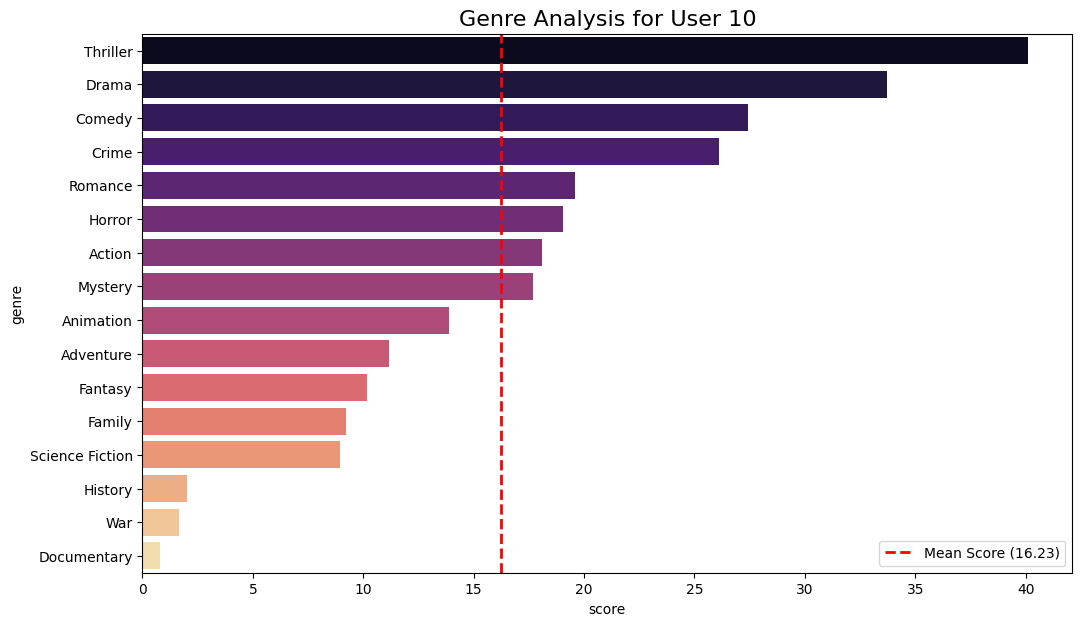

--- Top 15 gợi ý cho User 10 ---
Movie ID 9452 - Avg Genre Score: 29.39, User Avg Score: 16.23
Movie ID 26185 - Avg Genre Score: 27.14, User Avg Score: 16.23
Movie ID 18763 - Avg Genre Score: 29.09, User Avg Score: 16.23
Movie ID 10403 - Avg Genre Score: 29.01, User Avg Score: 16.23
Movie ID 11027 - Avg Genre Score: 29.88, User Avg Score: 16.23
Movie ID 25066 - Avg Genre Score: 25.82, User Avg Score: 16.23
Movie ID 1547 - Avg Genre Score: 27.98, User Avg Score: 16.23
Movie ID 13012 - Avg Genre Score: 29.50, User Avg Score: 16.23
Movie ID 42855 - Avg Genre Score: 29.50, User Avg Score: 16.23
Movie ID 28115 - Avg Genre Score: 29.50, User Avg Score: 16.23
Movie ID 1419406 - Avg Genre Score: 29.50, User Avg Score: 16.23
Movie ID 333354 - Avg Genre Score: 25.84, User Avg Score: 16.23
Movie ID 56329 - Avg Genre Score: 29.40, User Avg Score: 16.23
Movie ID 4193 - Avg Genre Score: 29.40, User Avg Score: 16.23
Movie ID 322 - Avg Genre Score: 29.40, User Avg Score: 16.23


,movie_id,title,genres,is_relevant
10400,9452,Bulworth,"Drama, Comedy, Thriller, Crime, Romance",True
4694,26185,McQ,"Drama, Action, Thriller, Crime, Mystery",True
5832,18763,Heart of Dragon,"Drama, Action, Comedy, Thriller, Crime",True
4113,10403,The Player,"Drama, Comedy, Thriller, Crime, Mystery",True
6586,11027,The Postman Always Rings Twice,"Drama, Thriller, Crime, Romance",True
7649,25066,Tales from the Hood,"Fantasy, Drama, Horror, Thriller, Crime",True
3437,1547,The Lost Boys,"Drama, Horror, Comedy, Thriller, Romance",True
30,13012,Felon,"Drama, Action, Thriller, Crime",True
3320,42855,Island of Greed,"Drama, Action, Thriller, Crime",True
2140,28115,Dillinger,"Drama, Action, Thriller, Crime",True


In [240]:
fav, unfav, genre_counts, avg_score = get_user_genres_preferences_on_time(USER_ID, df_interactions, df_movies)

import matplotlib.pyplot as plt
import seaborn as sns

def plot_genre_with_mean(genre_counts, avg_score, user_id):
    df_plot = pd.DataFrame.from_dict(genre_counts, orient='index', columns=['score']).reset_index()
    df_plot.columns = ['genre', 'score']
    df_plot = df_plot.sort_values(by='score', ascending=False)

    plt.figure(figsize=(12, 7))
    sns.barplot(x='score', y='genre', data=df_plot, palette='magma')

    # VẼ ĐƯỜNG TRUNG BÌNH
    plt.axvline(x=avg_score, color='red', linestyle='--', linewidth=2, label=f'Mean Score ({avg_score:.2f})')
    
    plt.title(f'Genre Analysis for User {user_id}', fontsize=16)
    plt.legend() # Hiển thị chú thích cho đường Mean
    plt.show()

plot_genre_with_mean(genre_counts, avg_score, USER_ID)

rcm, similarities = recommendations_for_user(USER_ID, df_interactions, tfidf_matrix, indices, df_movies, top_n=15)

rcm.rename(columns={'id': 'movie_id'}, inplace=True)

rcm["is_relevant"] = rcm['movie_id'].apply(lambda m_id: is_movie_relevant_weighted(m_id, df_movies, genre_counts, avg_score))
rcm

In [244]:
# 1. Lấy ra danh sách các index (số nhà) của top 15
top_indices = similarities.argsort()[-15:][::-1]

# 2. Dùng danh sách index đó để bốc giá trị từ mảng similarities
top_values = similarities[top_indices]

print(top_values)

[0.62980811 0.62807309 0.62326141 0.62155316 0.60611388 0.60225576
 0.59950233 0.59836772 0.59836772 0.59836772 0.59836772 0.5980033
 0.59634649 0.59634649 0.59634649]
